In [1]:
import kwant
import kwant.continuum
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as tck
import scipy.sparse.linalg as sla

from mpl_toolkits.axes_grid1 import make_axes_locatable
import scienceplots
plt.style.use(['science', 'notebook'])

# SOC Spectrum

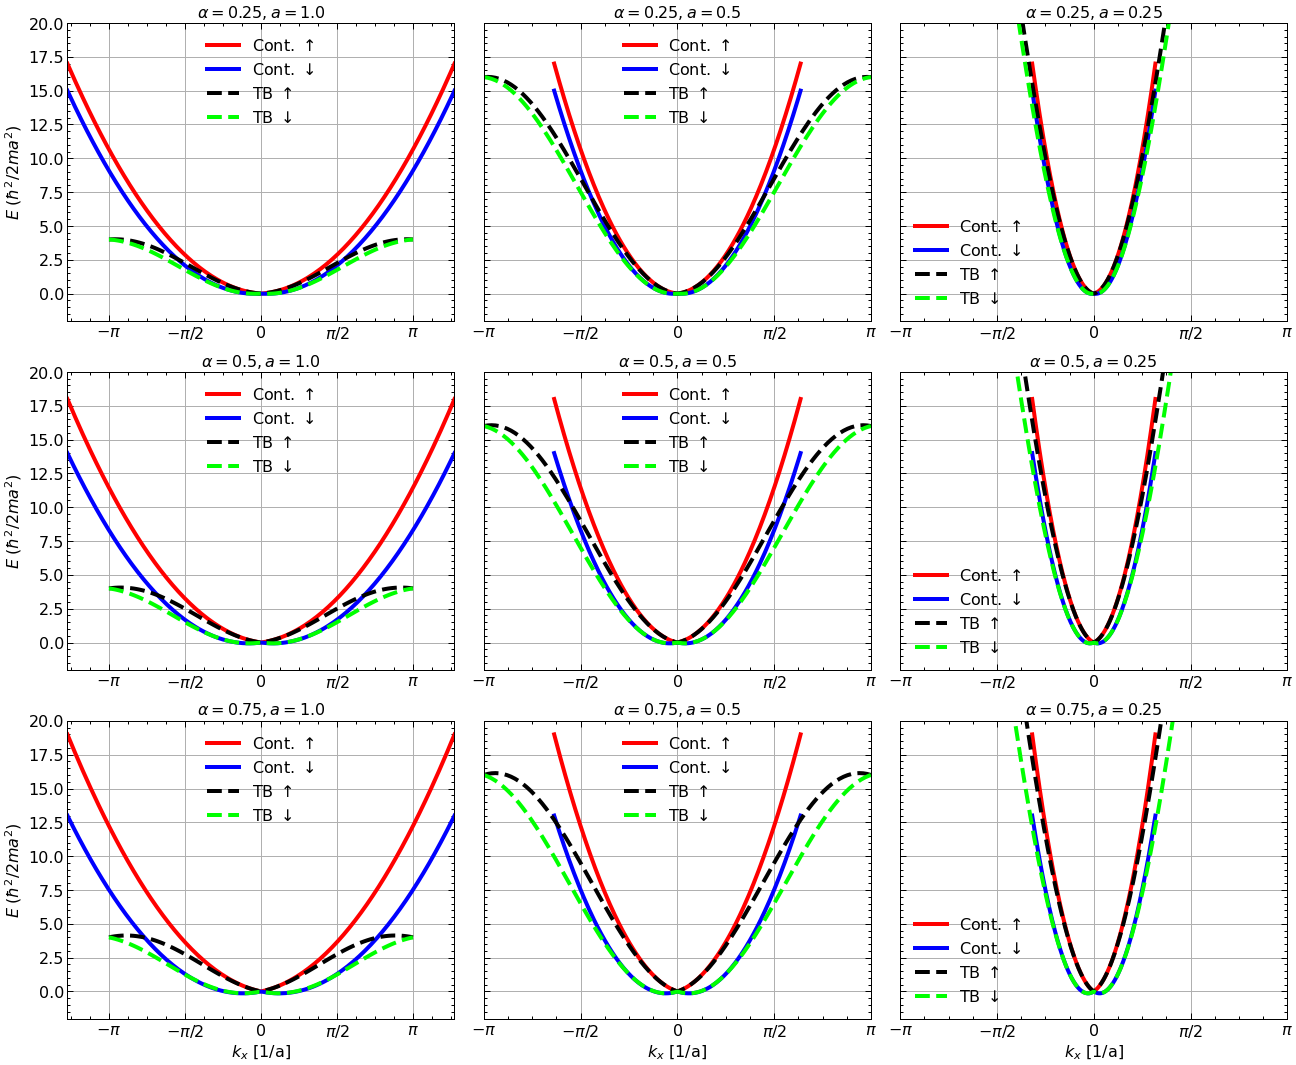

In [2]:
# ------------------------
# Pauli matrices
# ------------------------
s0 = np.array([[1, 0], [0, 1]])
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])

# ------------------------
# Parameters
# ------------------------
a_list = [1.0, 0.5, 0.25]
alpha_list = [0.25, 0.5, 0.75]
k_cont = np.linspace(-4, 4, 200)

# ------------------------
# Subplots: rows = len(alpha_list), columns = len(a_list)
# ------------------------
fig, axes = plt.subplots(len(alpha_list), len(a_list), figsize=(6*len(a_list),5*len(alpha_list)), sharey=True, sharex=False)
# Make axes 2D array even if len=1
if len(alpha_list)==1: axes = np.array([axes])
if len(a_list)==1: axes = np.array([[ax] for ax in axes])

for i_alpha, alpha in enumerate(alpha_list):
    for j_a, a in enumerate(a_list):
        ax = axes[i_alpha, j_a]
        params = dict(alpha=alpha, mu=0, s0=s0, sy=sy)

        # --- Continuum ---
        hamiltonian = "(k_x**2 - mu) * s0 + alpha * k_x * sy"
        H_k = kwant.continuum.lambdify(hamiltonian, locals=params)
        e_cont = [H_k(k_x=k) for k in k_cont]
        e_cont_up   = [np.linalg.eigvalsh(E)[1] for E in e_cont]
        e_cont_down = [np.linalg.eigvalsh(E)[0] for E in e_cont]

        # --- Discretize ---
        template = kwant.continuum.discretize(hamiltonian, grid=a)
        lead = kwant.Builder(kwant.TranslationalSymmetry([-a]))
        lead.fill(template, shape=lambda site: True, start=[0])
        lead = lead.finalized()

        # --- TB energies ---
        k_tb = np.linspace(-np.pi/a, np.pi/a, int(100/a))
        bands = kwant.physics.Bands(lead, params=params)
        e_tb_up   = [bands(k*a)[1] for k in k_tb]
        e_tb_down = [bands(k*a)[0] for k in k_tb]

        # --- Plot ---
        ax.plot(k_cont, e_cont_up, 'r-', lw=4, label=r'Cont. $\uparrow$')
        ax.plot(k_cont, e_cont_down, 'b-', lw=4, label=r'Cont. $\downarrow$')
        ax.plot(k_tb, e_tb_up, 'k--', lw=4, label=r'TB $\uparrow$')
        ax.plot(k_tb, e_tb_down, '--', color='lime', lw=4, label=r'TB $\downarrow$')

        ax.set_title(f"$\\alpha={alpha}, a={a}$")
        ax.grid(True)
        ax.legend(fontsize=16)
        ax.set_ylim(-2,20)
        ax.set_xlim(-4, 4)

        # X ticks in units of pi
        ticks = np.array([-np.pi, -np.pi/2, 0, np.pi/2, np.pi]) / a
        labels = [r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"]
        ax.set_xticks(ticks)
        ax.set_xticklabels(labels)

# Common labels
for ax_row in axes[:,0]:
    ax_row.set_ylabel(r"$E\;(\hbar^2 / 2 m a^2)$")
for ax_col in axes[-1,:]:
    ax_col.set_xlabel(r"$k_x$ [1/a]")

plt.tight_layout()
plt.show()

# Spin resolved conductance from lead_0 to lead_1

In [3]:
def make_system(a,t,L,mu,mu_lead):

    lat = kwant.lattice.chain(a, norbs=2)
    
    # Define the system
    syst = kwant.Builder()
    # Onsite
    syst[(lat(i) for i in range(L))] = (2 * t - mu) * s0
    # Hopping
    syst[kwant.builder.HoppingKind((1, ), lat)] = -t * s0 - 0.5j * alpha * sy
    
    #### Define the leads. ####
    
    lead_left = kwant.Builder(kwant.TranslationalSymmetry((-a, )))
    lead_left[(lat(0))] = ( 2 * t - mu_lead ) * s0
    lead_left[kwant.builder.HoppingKind((1, ), lat)] = -t * s0

    syst.attach_lead(lead_left)
    syst.attach_lead(lead_left.reversed())

    return syst

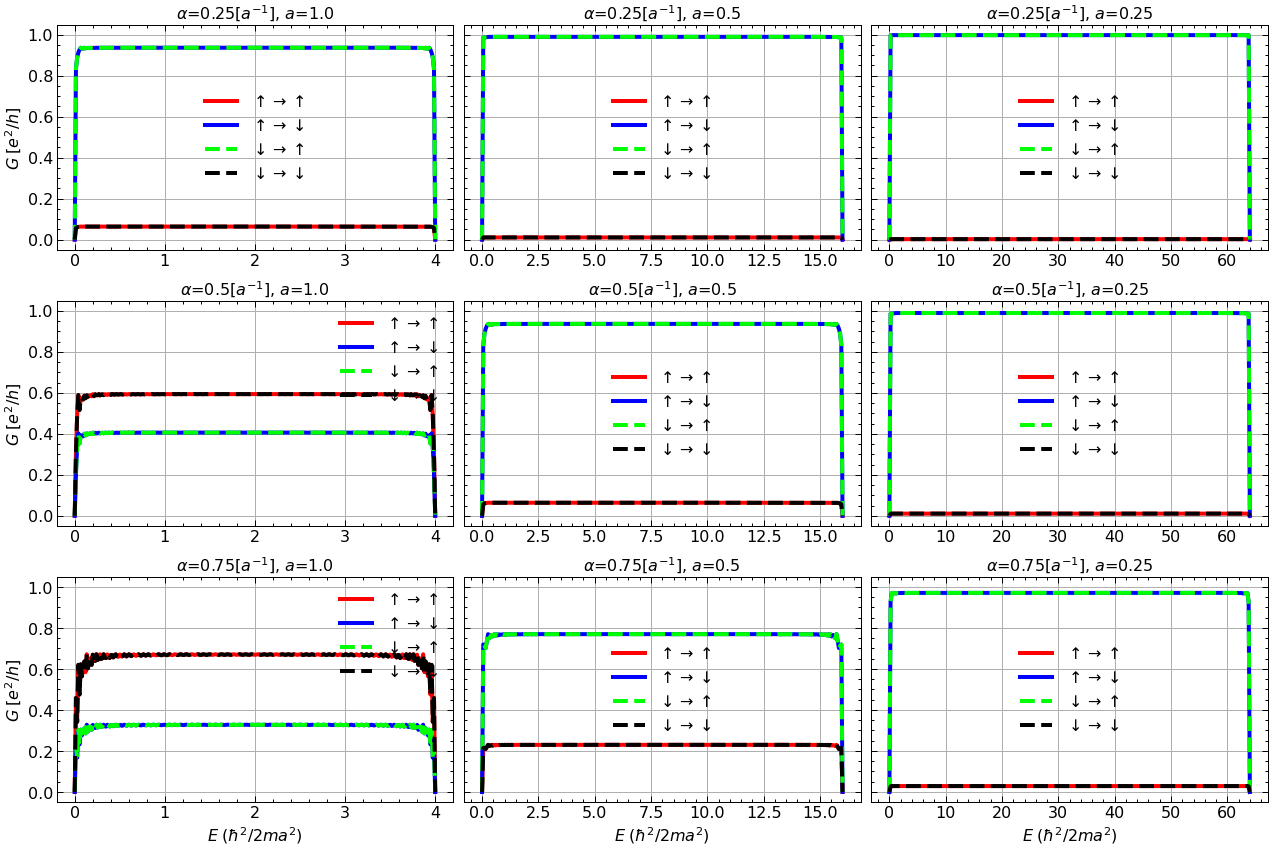

In [6]:
import kwant
import numpy as np
from matplotlib import pyplot as plt

# ------------------------
# Pauli matrices
# ------------------------
s0 = np.array([[1, 0], [0, 1]])
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])

# ------------------------
# Lead builder (spinful, no SOC)
# ------------------------
def make_lead(a, t, mu_lead):
    lat = kwant.lattice.chain(a, norbs=2)
    lead = kwant.Builder(kwant.TranslationalSymmetry((-a,)))
    lead[(lat(0))] = (2*t - mu_lead) * s0
    lead[kwant.builder.HoppingKind((-1,), lat)] = -t * s0
    return lead

# ------------------------
# System builder (spinful + Rashba SOC)
# ------------------------
def make_system(L, mu, mu_lead, a, t, alpha):
    lat = kwant.lattice.chain(a, norbs=2)
    syst = kwant.Builder()
    syst[(lat(i) for i in range(L))] = (2*t - mu) * s0
    syst[kwant.builder.HoppingKind((1,), lat)] = -t * s0 - 0.5j * alpha * sy

    left_lead = make_lead(a, t, mu_lead)
    syst.attach_lead(left_lead)
    syst.attach_lead(left_lead.reversed())
    return syst

# ------------------------
# Spin-resolved conductance
# ------------------------
def compute_spin_conductance(fsyst, energies):
    G = {"up->up":[], "up->down":[], "down->up":[], "down->down":[]}
    for energy in energies:
        smatrix = kwant.smatrix(fsyst, energy)
        S = smatrix.submatrix(1,0)
        G["up->up"].append(np.abs(S[0,0])**2)
        G["up->down"].append(np.abs(S[1,0])**2)
        G["down->up"].append(np.abs(S[0,1])**2)
        G["down->down"].append(np.abs(S[1,1])**2)
    return {k: np.array(v) for k,v in G.items()}

# ------------------------
# Parameters
# ------------------------
L = 100
mu = 0
mu_lead = 0
a_list = [1.0, 0.5, 0.25]
alpha_list = [0.25, 0.5, 0.75]

# ------------------------
# Plotting: 2D grid
# ------------------------
fig, axes = plt.subplots(len(alpha_list), len(a_list), figsize=(6*len(a_list),4*len(alpha_list)), sharex=False, sharey=True)

for i_alpha, alpha in enumerate(alpha_list):
    for j_a, a in enumerate(a_list):
        ax = axes[i_alpha, j_a]

        t = 1 / a**2
        syst = make_system(L, mu, mu_lead, a, t, alpha/a)
        fsyst = syst.finalized()

        energies = np.linspace(1e-12, 4*t - 1e-12, 300)
        G_spin = compute_spin_conductance(fsyst, energies)

        # Plot spin-resolved conductance
        ax.plot(energies, G_spin["up->up"], 'r-', lw=4, label=r"$\uparrow \to \uparrow$")
        ax.plot(energies, G_spin["up->down"], 'b-', lw=4, label=r"$\uparrow \to \downarrow$")
        ax.plot(energies, G_spin["down->up"], '--', color='lime', lw=4, label=r"$\downarrow \to \uparrow$")
        ax.plot(energies, G_spin["down->down"], 'k--', lw=4, label=r"$\downarrow \to \downarrow$")

        ax.set_title(r"$\alpha$="f'{alpha}'r"$[a^{-1}]$, " r"$a$="f'{a}')
        ax.grid(True)
        ax.legend(fontsize=16)  # Her subplot için legend

        if i_alpha == len(alpha_list)-1:
            ax.set_xlabel(r"$E\;(\hbar^2 / 2 m a^2)$")
        if j_a == 0:
            ax.set_ylabel(r"$G \; [e^2/h]$")

plt.tight_layout()
plt.show()

# Spin-Resolved Conductance in Kwant

This document explains how **spin-resolved conductance** is computed in a quantum system with spin-orbit coupling using Kwant.

---

## 1. Scattering Matrix (S-matrix)

The scattering matrix is obtained via:

```python
smatrix = kwant.smatrix(fsyst, energy)
```

* Contains **complex transmission amplitudes** between **all channels** in all leads.
* For a **spinful system**, each lead has 2 channels: **spin-up (↑)** and **spin-down (↓)**.

---

## 2. Extract Transmission Submatrix

To get the transmission from **input lead 0** to **output lead 1**:

```python
S = smatrix.submatrix(1, 0)
```

For spinful leads, `S` is a **2×2 matrix**:

| Output \ Input | ↑      | ↓      |
| -------------- | ------ | ------ |
| ↑              | S[0,0] | S[0,1] |
| ↓              | S[1,0] | S[1,1] |

---

## 3. Spin-Resolved Conductance

The **spin-resolved conductances** are:

* `G[↑→↑] = |S[0,0]|^2` → up spin **remains up**
* `G[↑→↓] = |S[1,0]|^2` → up spin **flips to down**
* `G[↓→↑] = |S[0,1]|^2` → down spin **flips to up**
* `G[↓→↓] = |S[1,1]|^2` → down spin **remains down**

> The squared magnitude gives the **transmission probability**, i.e., conductance in units of `e^2/h`.

---

## 4. Energy Dependence

Looping over an energy array produces spin-resolved conductances as a function of energy:

```python
for E in energies:
    smatrix = kwant.smatrix(fsyst, E)
    # extract S-matrix and compute spin conductances
```

* Produces `G(E)` for each spin channel.
* Enables plotting:
  `E vs G[↑→↑], G[↑→↓], G[↓→↑], G[↓→↓]`

---

## 5. Physical Interpretation

| Condition      | Spin-Conserving | Spin-Flip       |
| -------------- | --------------- | --------------- |
| **No SOC**     | ↑→↑, ↓→↓ ≈ 1    | ↑→↓, ↓→↑ ≈ 0    |
| **With SOC**   | decreases       | becomes nonzero |
| **TB small a** | partial         | ↑→↓ ~ 1         |
| **Continuum**  | gradual         | max ↑→↓ ~ 0.5   |

* **No SOC:** spin is conserved.
* **With SOC:** spin precesses along the system.
* **Smaller lattice spacing (a)** in TB → stronger effective SOC → larger spin-flip probability.
* **Continuum limit:** spin precession is gradual → partial spin-flip.

---

### Summary

* The **S-matrix** encodes all spin channels.
* Extracting the **2×2 submatrix** gives **spin-resolved transmission probabilities**.
* Plotting `G_spin(E)` reveals both **spin-conserving** and **spin-flip** contributions as functions of energy and SOC strength.
